# Step 1: Frame Extraction & Annotation

This notebook covers:
1. Extract representative frames from `sample.mp4`
2. Preview extracted frames
3. Annotation guide using LabelImg

**Output:** `dataset/images/all/` — raw frames ready for annotation

## 1.1 Install Dependencies

In [ ]:
%pip install opencv-python matplotlib labelImg==1.8.6 -q

## 1.2 Extract Frames

Frames are sampled at a fixed interval from the source video.

| Parameter | Value | Reason |
|---|---|---|
| `SAMPLE_RATE` | 4 | Every 4 frames ≈ 6.25 fps — balances coverage and redundancy |
| `VIDEO_PATH` | sample.mp4 | Source footage from FootfallCam 3D sensor |
| `OUTPUT_DIR` | dataset/images/all | Staging directory for annotation |

In [2]:
import cv2
import os

# ── Configuration ─────────────────────────────────────
VIDEO_PATH  = "sample.mp4"
OUTPUT_DIR  = "dataset/images/all"
SAMPLE_RATE = 4              # Extract one frame every N frames

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Video info ────────────────────────────────────────
cap          = cv2.VideoCapture(VIDEO_PATH)
fps          = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"FPS            : {fps}")
print(f"Total frames   : {total_frames}")
print(f"Resolution     : {width} x {height}")
print(f"Duration       : {total_frames/fps:.2f} seconds")
print(f"Sample rate    : every {SAMPLE_RATE} frames")
print(f"Expected output: ~{total_frames//SAMPLE_RATE} images")

FPS            : 25.0
Total frames   : 1341
Resolution     : 960 x 720
Duration       : 53.64 seconds
Sample rate    : every 4 frames
Expected output: ~335 images


In [3]:
# ── Extract frames ────────────────────────────────────
frame_idx   = 0
saved_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % SAMPLE_RATE == 0:
        filename = os.path.join(OUTPUT_DIR, f"frame_{frame_idx:05d}.jpg")
        cv2.imwrite(filename, frame)
        saved_count += 1

    frame_idx += 1

cap.release()
print(f"Done. Saved {saved_count} frames to '{OUTPUT_DIR}'")

Done. Saved 336 frames to 'dataset/images/all'


## 1.3 Preview Extracted Frames

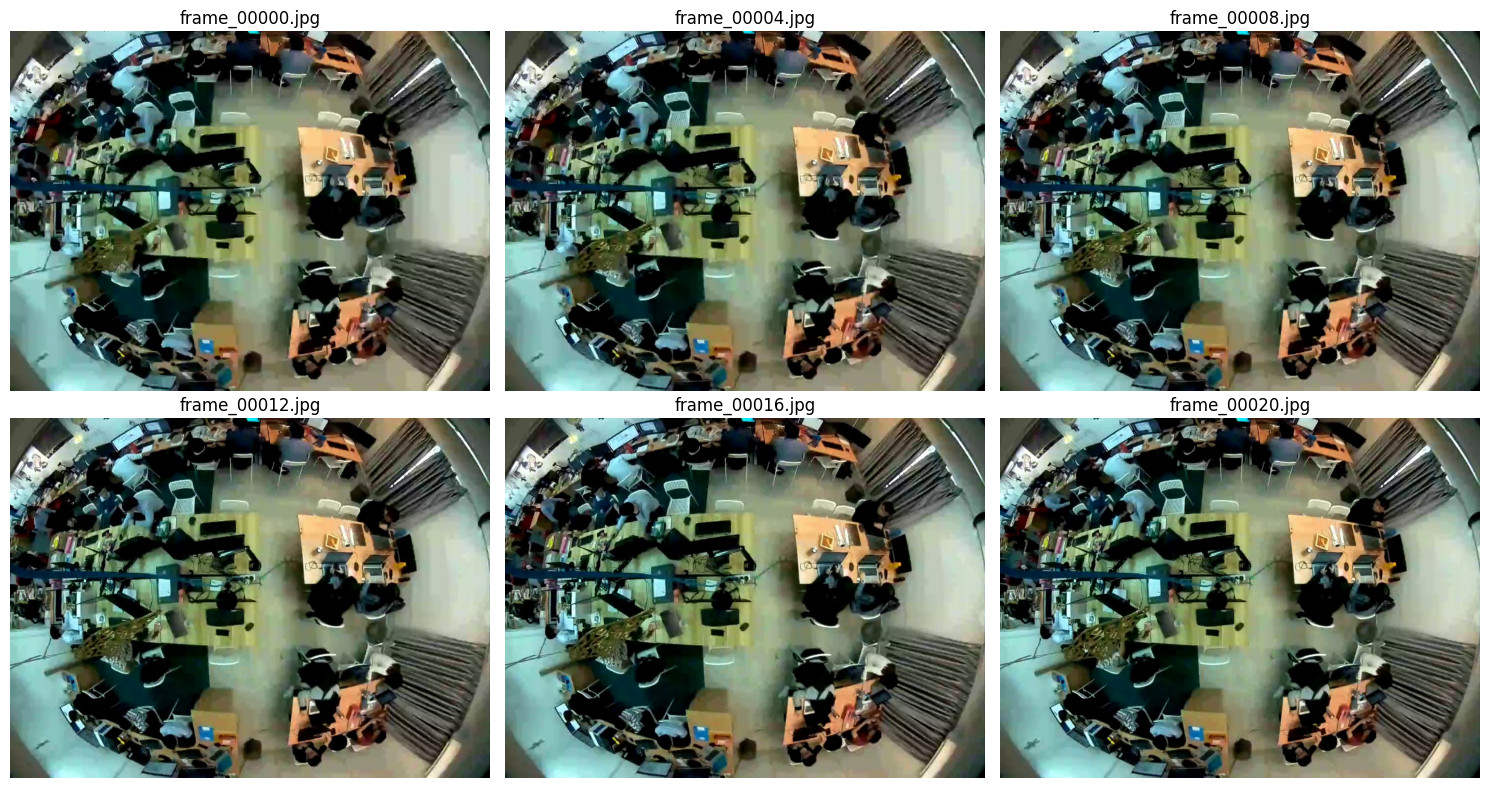

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ── Preview first 6 frames ────────────────────────────
samples = sorted([f for f in os.listdir(OUTPUT_DIR) if f.endswith(".jpg")])[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, fname in zip(axes.flatten(), samples):
    img = mpimg.imread(os.path.join(OUTPUT_DIR, fname))
    ax.imshow(img)
    ax.set_title(fname)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 1.4 Annotation Guide (LabelImg)

Annotate staff name tags in the extracted frames using LabelImg.

### Setup

Launch LabelImg from terminal:
```bash
labelImg
```

### Configuration

| Step | Action |
|---|---|
| 1 | Click **Open Dir** → select `dataset/images/all/` |
| 2 | Click **Change Save Dir** → select the same `dataset/images/all/` |
| 3 | Set format to **YOLO** (bottom-left panel) |

### Labelling Rules

- Class name: **`staff_tag`**
- Draw the bounding box tightly around the name tag only
- Annotate **only frames where the name tag is clearly visible**
- Skip frames where the name tag is heavily blurred or fully occluded
- Frames with **no name tag** require no annotation file — YOLO treats them as negative (background) samples automatically

### Output

Each annotated frame produces a `.txt` file in YOLO format:
```
0  x_center  y_center  width  height
```
All values are normalised to [0, 1] relative to image dimensions.